# Prediction Race Winner

## Objevtive

Predict if a driver will win a race (1: Win 0: No) with previous information.

## Utils

**races.csv**:
- raceId: ID race
- year, round, date: Cronologic order
- circuitId: To join circuits.csv
- name: Name of GP

**results.csv**:
- raceId, driverId, constructorId, grid, position, statusId
- positionOrder: TARGET
- points: points obtained

**driver.csv**:
- driverId, dob, nationality
- races.date - dob: Age of that moment.

**constructors.csv**:
- constructorId, name, nationality

**qualifying.csv**:
- raceId, driverId, position
- q1, q2, q3

**circuits.csv**:
- circuitId, name, location, country



## Generate Dataset

In [14]:
import pandas as pd

from datetime import datetime

# LOAD DATA
races = pd.read_csv('../data/original/races.csv')
results = pd.read_csv('../data/original/results.csv')
drivers = pd.read_csv('../data/original/drivers.csv')
constructors = pd.read_csv('../data/original/constructors.csv')
circuits = pd.read_csv('../data/original/circuits.csv')
qualifying = pd.read_csv('../data/original/qualifying.csv')

races['date'] = pd.to_datetime(races['date'], errors='coerce')
drivers['dob'] = pd.to_datetime(drivers['dob'], errors='coerce')

# JOIN DATA
df = results.merge(races[['raceId', 'year', 'round', 'date', 'circuitId']], on='raceId', how='left')
df = df.merge(drivers, on='driverId', how='left')
df = df.merge(constructors, on='constructorId', how='left')
df = df.merge(circuits, on='circuitId', how='left')

# FEATURE ENGINEERING
df['driver_age'] = (df['date'] - df['dob']).dt.days // 365
df['won'] = df['positionOrder'].apply(lambda x: 1 if x == 1 else 0)


if not qualifying.empty:
    quali_pos = qualifying[['raceId', 'driverId', 'position']].rename(columns={'position': 'quali_position'})
    df = df.merge(quali_pos, on=['raceId', 'driverId'], how='left')
else:
    df['quali_position'] = df['grid']
    
    
# KEEP COLUMNS
columns_to_keep = [
    'raceId', 'year', 'round', 'date',
    'driverId', 'forename', 'surname', 'nationality_x', 'driver_age',
    'constructorId', 'name_y', 'nationality_y',
    'circuitId', 'country', 'location',
    'grid', 'quali_position',
    'positionOrder', 'won'
]

final_df = df[columns_to_keep].rename(columns={
    'nationality_x': 'driver_nationality',
    'nationality_y': 'constructor_nationality',
    'name_y': 'constructor_name'
})

print(final_df.head())

final_df.to_csv('../data/train/f1_results.csv', index=False)


   raceId  year  round       date  driverId  forename     surname  \
0      18  2008      1 2008-03-16         1     Lewis    Hamilton   
1      18  2008      1 2008-03-16         2      Nick    Heidfeld   
2      18  2008      1 2008-03-16         3      Nico     Rosberg   
3      18  2008      1 2008-03-16         4  Fernando      Alonso   
4      18  2008      1 2008-03-16         5    Heikki  Kovalainen   

  driver_nationality  driver_age  constructorId  \
0            British          23              1   
1             German          30              2   
2             German          22              3   
3            Spanish          26              4   
4            Finnish          26              1   

                 constructor_name constructor_nationality  circuitId  \
0  Albert Park Grand Prix Circuit                 British          1   
1  Albert Park Grand Prix Circuit                  German          1   
2  Albert Park Grand Prix Circuit                 British     

## Preprocessing

### Missing Values

In [15]:
df = pd.read_csv('../data/train/f1_results.csv')

print("Missing values in the dataset:")
print(df.isnull().sum())

Missing values in the dataset:
raceId                         0
year                           0
round                          0
date                           0
driverId                       0
forename                       0
surname                        0
driver_nationality             0
driver_age                     0
constructorId                  0
constructor_name               0
constructor_nationality        0
circuitId                      0
country                        0
location                       0
grid                           0
quali_position             16265
positionOrder                  0
won                            0
dtype: int64


### Correlations


Correlations with 'won':
won               1.000000
driver_age        0.032354
year              0.012697
raceId            0.009803
round             0.002251
circuitId         0.001403
constructorId    -0.037460
driverId         -0.044150
grid             -0.245684
quali_position   -0.317438
positionOrder    -0.322758
Name: won, dtype: float64


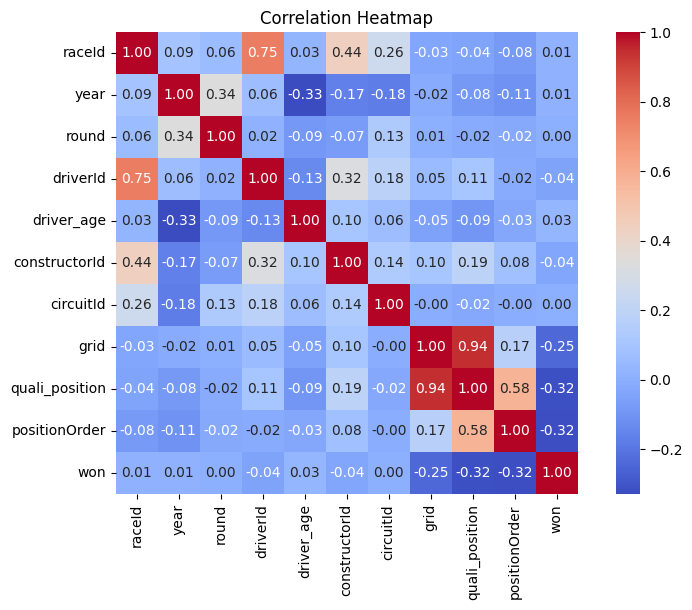

In [16]:
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

correlations = numeric_cols.corr()['won'].sort_values(ascending=False)
print("\nCorrelations with 'won':")
print(correlations)

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()

### Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# DELETE UNWANTED COLUMNS
df = df.drop(columns=['quali_position', 'forename', 'surname', 'location'])

y = df['won']
X = df.drop('won', axis=1)

numeric_cols = [cname for cname in X.columns if X[cname].dtype in ['float64', 'int64']]
categorical_cols = [cname for cname in X.columns if X[cname].dtype == 'object']


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf_pipeline.fit(X_train, y_train)
y_pred = clf_pipeline.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5126
           1       1.00      1.00      1.00       226

    accuracy                           1.00      5352
   macro avg       1.00      1.00      1.00      5352
weighted avg       1.00      1.00      1.00      5352

Accuracy: 0.999813153961136


In [18]:
import numpy as np
unique_preds, counts = np.unique(y_pred, return_counts=True)
print(dict(zip(unique_preds, counts)))

{np.int64(0): np.int64(5127), np.int64(1): np.int64(225)}
